## Data Creation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from custom.models.feedforward_neural_network import FeedForwardNeuralNetwork
from custom.models.decision_tree import DecisionTree
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from sklearn.base import RegressorMixin
import pandas as pd


In [2]:
def get_sine_data(n_samples=100, X = None):
    if X is None:
        X = np.random.uniform(-np.pi, np.pi, (n_samples, 1))
    y = np.sin(X) + np.random.normal(0, 0.5, (n_samples, 1))
    return X, y, lambda x: np.sin(x)

def get_linear_data(n_samples=100, X = None):
    if X is None:
        X = np.random.uniform(0, 10, (n_samples, 1))
    y = 2*X + 1 + np.random.normal(0, 0.5, (n_samples, 1))
    return X, y, lambda x: 2*x + 1

def get_quadratic_data(n_samples=100, X = None):
    if X is None:
        X = np.random.uniform(0, 10, (n_samples, 1))
    y = 2*X*X + 1 + np.random.normal(0, 5, (n_samples, 1))
    return X, y, lambda x: 2*x*x + 1

[('FFNN with early stopping and weight decay', (<custom.models.feedforward_neural_network.FeedForwardNeuralNetwork object at 0x7fb4580303b0>, MLPRegressor(alpha=0.01, batch_size=32, early_stopping=True,
             hidden_layer_sizes=[10, 10, 10], max_iter=1000, random_state=50))), ('DT with all parameters', (<custom.models.decision_tree.DecisionTree object at 0x7fb45720d1c0>, DecisionTreeRegressor(max_depth=5, min_impurity_decrease=0.01,
                      min_samples_leaf=25, min_samples_split=100)))]


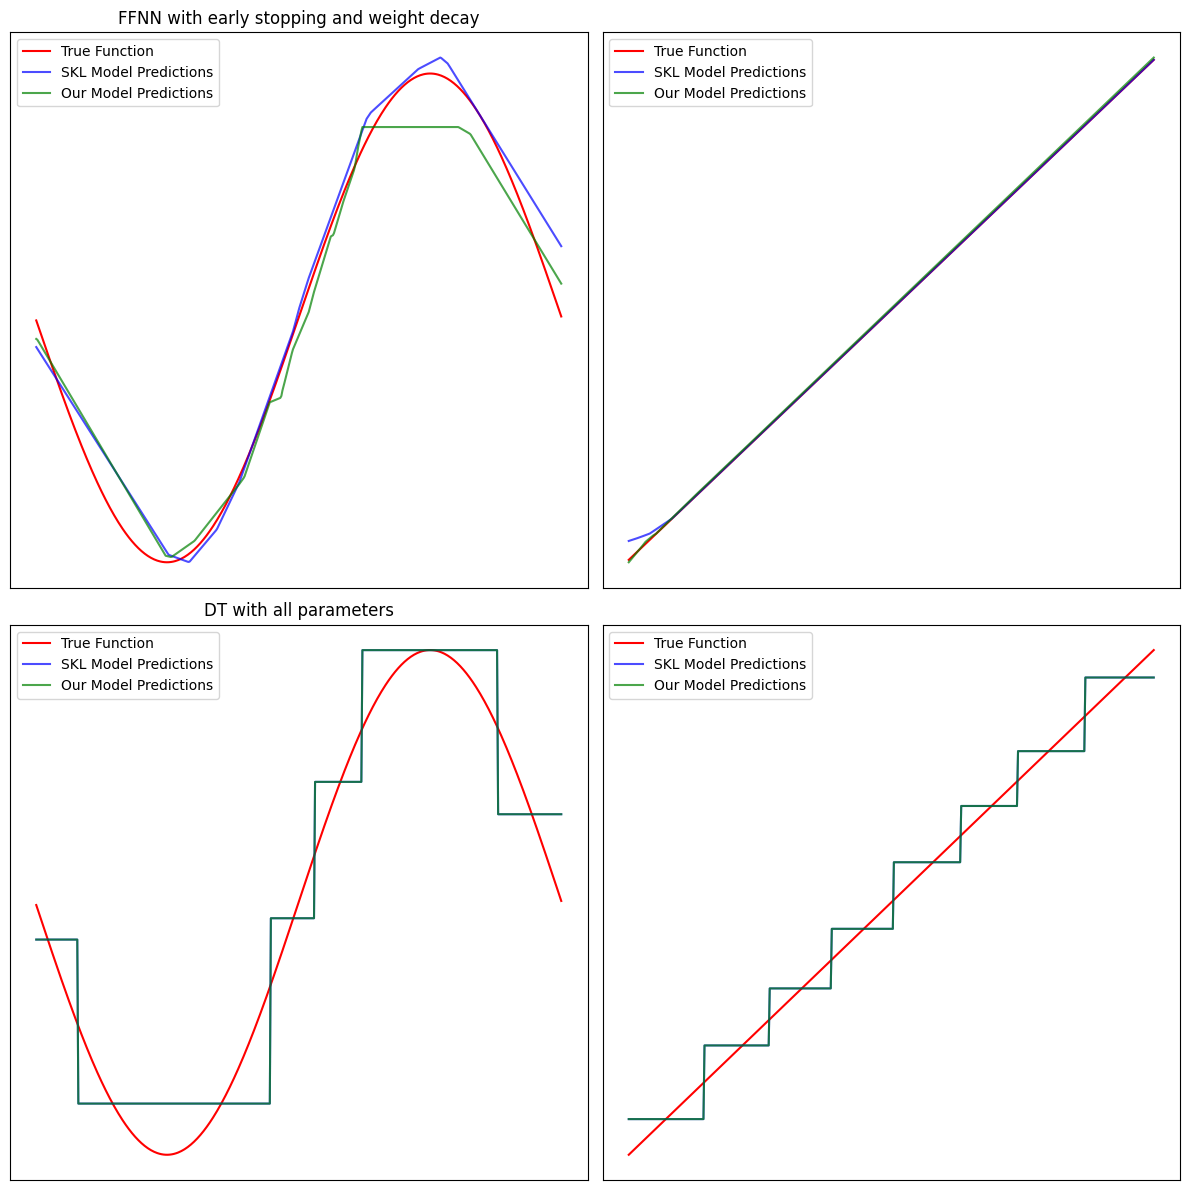

In [32]:
from typing import Callable
import random

random_seed = 50

models = {
"FFNN with no hyperparameters": (FeedForwardNeuralNetwork([10, 10, 10],  epochs=1000, learning_rate=0.001, regression=True, auto_save=False, random_state=random_seed),
                          MLPRegressor(hidden_layer_sizes=[10, 10, 10], learning_rate_init=0.001, max_iter=1000, random_state=random_seed)),
"FFNN with early stopping": (FeedForwardNeuralNetwork([10, 10, 10], epochs=1000, learning_rate=0.001, patience=10, regression=True, auto_save=False, random_state=random_seed),
                          MLPRegressor(hidden_layer_sizes=[10, 10, 10], max_iter=1000, learning_rate_init=0.001, early_stopping=True, random_state=random_seed)),
"FFNN with weight decay": (FeedForwardNeuralNetwork([10, 10, 10], epochs=1000, learning_rate=0.001, patience=10, regularization_setting=(2, 0.01), regression=True, auto_save=False, random_state=random_seed),
                          MLPRegressor(hidden_layer_sizes=[10, 10, 10], max_iter=1000, learning_rate_init=0.001, alpha=0.01, early_stopping=True, random_state=random_seed)),
"FFNN with early stopping and weight decay": (FeedForwardNeuralNetwork([10, 10, 10], epochs=1000, learning_rate=0.001, patience=10, batch_size=32, regularization_setting=(2, 0.01), regression=True, auto_save=False, random_state=random_seed),
                          MLPRegressor(hidden_layer_sizes=[10, 10, 10], max_iter=1000, learning_rate_init=0.001, batch_size=32 , alpha=0.01, early_stopping=True, random_state=random_seed)),
"DT with no hyperparameters": (DecisionTree(), DecisionTreeRegressor()),
"DT with max depth": (DecisionTree(max_depth=5), DecisionTreeRegressor(max_depth=5)),
"DT with min samples split": (DecisionTree(min_to_split=100), DecisionTreeRegressor(min_samples_split=100)),
"DT with min samples leaf": (DecisionTree(min_samples_leaf=25), DecisionTreeRegressor(min_samples_leaf=25)),
"DT with min impurity decrease": (DecisionTree(min_impurity_decrease=0.01), DecisionTreeRegressor(min_impurity_decrease=0.01)),
"DT with all parameters": (DecisionTree(max_depth=5, min_to_split=100, min_samples_leaf=25, min_impurity_decrease=0.01), DecisionTreeRegressor(max_depth=5, min_samples_split=100, min_samples_leaf=25, min_impurity_decrease=0.01))
}
funcs = [get_sine_data, get_linear_data]

def compare_regressors_on_functions(models: dict[str, tuple[RegressorMixin, RegressorMixin]], funcs: list[Callable], some: bool = True) -> None: # models tuple expect our model and sklearn model in that order
    models = list(models.items())
    if some:
        model1 = models[3]
        model2 = models[-1]
        models = [model1, model2]
    fig, axs = plt.subplots(len(models), len(funcs), figsize=(6*len(funcs), 6*len(models)))
    print(models)
    for i, func in enumerate(funcs):
        X, y, true_function = func(n_samples=500)
        x_base = np.linspace(X.min(), X.max(), 500).flatten()

        for j, (model_cat, models_to_compare) in enumerate(models):
            our_model, skl_model = models_to_compare
            our_model.fit(X, y)
            skl_model.fit(X, y.ravel())
            y_pred_our = our_model.predict(x_base.reshape(-1, 1))
            y_pred_skl = skl_model.predict(x_base.reshape(-1, 1))
            
            ax = axs[j, i] if len(models) > 1 else axs[i]
    
            ax.plot(x_base, true_function(x_base), color='red', label='True Function')
            ax.plot(x_base, y_pred_skl, color='blue', label='SKL Model Predictions', alpha=0.7)
            ax.plot(x_base, y_pred_our, color='green', label='Our Model Predictions', alpha=0.7)
            ax.axes.get_xaxis().set_visible(False)
            ax.axes.get_yaxis().set_visible(False)
            if i == 0:
                ax.set_title(model_cat)
            ax.legend()
    fig.tight_layout()
    return fig

fig = compare_regressors_on_functions(models, funcs)
fig.savefig("Report/figs/correctness_tests/example_continuous_input_comparison.pdf")

# Categorical Variables Test

/home/sakul/UNI/3rd Semester/Machine Learning/ITU-MachineLearning-FinalProject-Couriers/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sakul/UNI/3rd Semester/Machine Learning/ITU-MachineLearning-FinalProject-Couriers/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


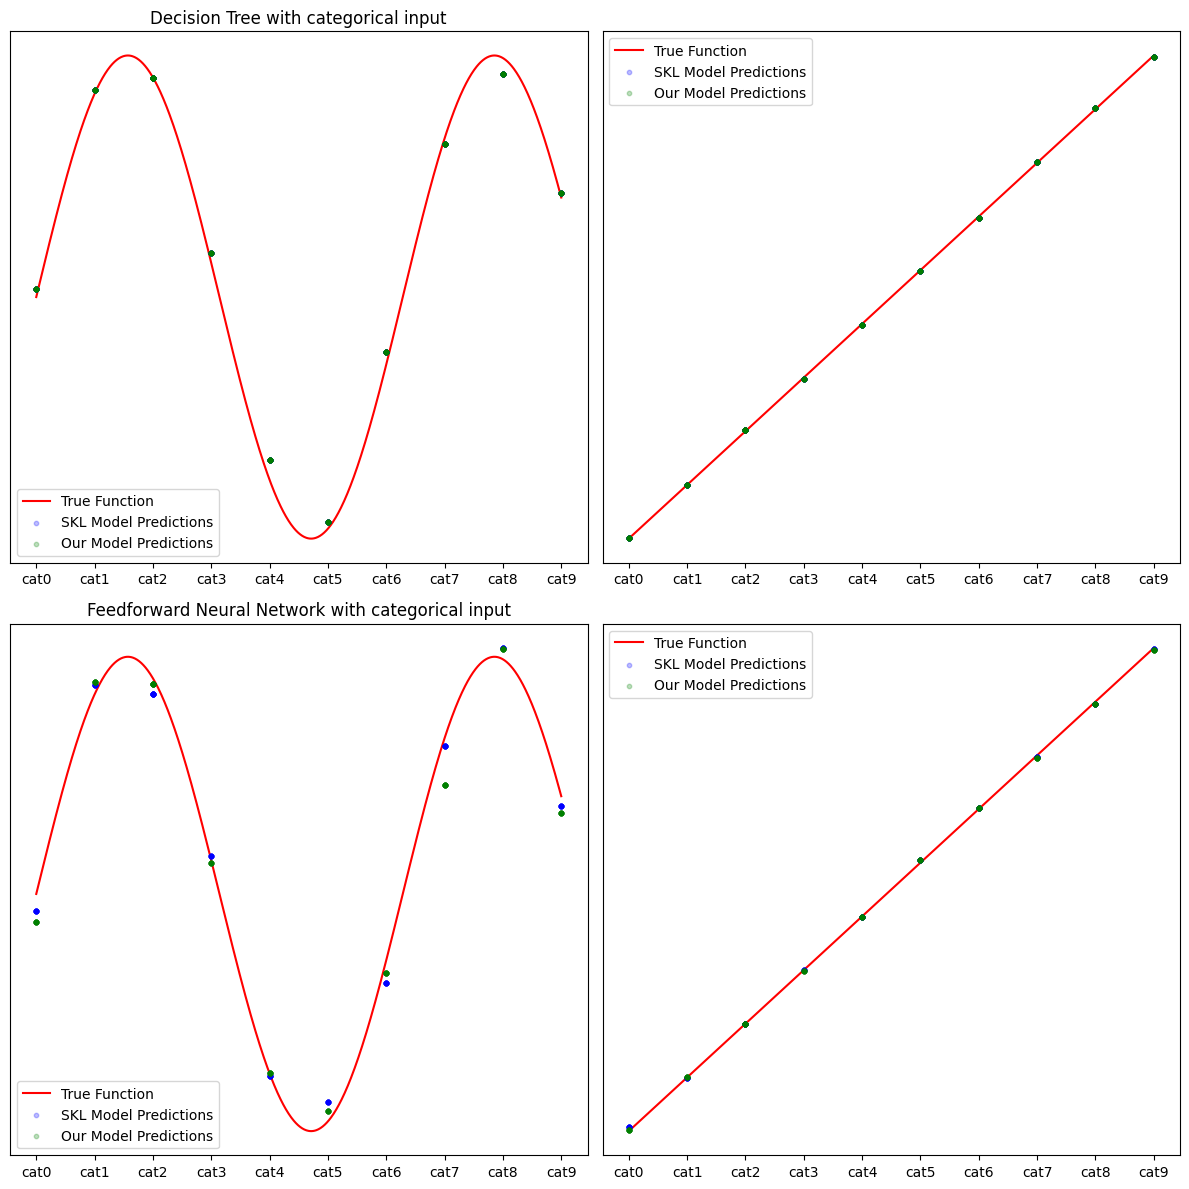

In [33]:
cat_values = np.random.randint(0, 10, size=(1000, 1))
X = OneHotEncoder().fit_transform(cat_values).toarray()

funs = [get_sine_data, get_linear_data]

dt_sklearn = DecisionTreeRegressor()
dt_our = DecisionTree()
FFNN_sklearn = MLPRegressor(hidden_layer_sizes=[10,10,10], max_iter=1000, learning_rate_init=0.001)
FFNN_our = FeedForwardNeuralNetwork([10,10,10], epochs=1000, learning_rate=0.001, regression=True, auto_save=False)

models_cat = [
    (dt_sklearn, dt_our, "Decision Tree"),
    (FFNN_sklearn, FFNN_our, "Feedforward Neural Network")
]

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

for i, (model_sklearn, model_our, model_name) in enumerate(models_cat):
    for j, func in enumerate(funcs):
        _, y, true_func = func(1000, cat_values)
        x_base = np.linspace(cat_values.min(), cat_values.max(), 1000).flatten()
        y_base = true_func(x_base)
        model_sklearn.fit(X, y)
        model_our.fit(X, y)

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        ax = axs[i, j]
        ax.plot(x_base, y_base, label='True Function', c="red", zorder=0)
        ax.scatter(np.argmax(X_test, axis=1), model_sklearn.predict(X_test), label='SKL Model Predictions', c="blue", s=10, alpha=0.25)
        ax.scatter(np.argmax(X_test, axis=1), model_our.predict(X_test), label='Our Model Predictions', c="green", s=10, alpha=0.25)
        if j == 0:
            ax.set_title(f"{model_name} with categorical input")
        ax.set_xticks(range(10))
        ax.set_xticklabels([f"cat{i}" for i in range(10)])
        ax.axes.get_yaxis().set_visible(False)
        ax.legend()

fig.tight_layout()

fig.savefig("Report/figs/correctness_tests/categorical_input_comparison.pdf")

In [ ]:
ordered_mses = [(mean_squared_error(y_test, y_pred_our), model_name) for _, y_pred_our, model_name in y_preds]

perm = np.random.permutation(X.shape[1])
X_shuffled = X[:, perm]

X_train, X_test, y_train, y_test = train_test_split(X_shuffled, y, test_size=0.2)

dt_sklearn = DecisionTreeRegressor().fit(X_train, y_train)
dt_our = DecisionTree().fit(X_train, y_train)
FFNN_sklearn = MLPRegressor(hidden_layer_sizes=[10,10], max_iter=1000).fit(X_train, y_train)
FFNN_our = FeedForwardNeuralNetwork([10,10], epochs=1000, learning_rate=0.001, regression=True, auto_save=False).fit(X_train, y_train)

y_pred_dt_sklearn = dt_sklearn.predict(X_test)
y_pred_dt_our = dt_our.predict(X_test)

y_pred_FFNN_sklearn = FFNN_sklearn.predict(X_test)
y_pred_FFNN_our = FFNN_our.predict(X_test)

y_preds = [
    (y_pred_dt_sklearn, y_pred_dt_our, "Decision Tree"),
    (y_pred_FFNN_sklearn, y_pred_FFNN_our, "Feedforward Neural Network")
]

unordered_mses = [(mean_squared_error(y_test, y_pred_our), model_name) for _, y_pred_our, model_name in y_preds]

# Print MSEs for ordered and unordered categorical features should be the same ish
print("Ordered MSEs:", ordered_mses)
print("Unordered MSEs:", unordered_mses)

def check_thresholds(node) -> None | float:
    """For categorical splits all thresholds should be the same and = 0.5"""
    my_threshold = node.threshold
    assert my_threshold == 0.5
    if not node.is_leaf:
        return None
    left_threshold = check_thresholds(node.left) if node.left else None
    right_threshold = check_thresholds(node.right) if node.right else None
    if left_threshold is not None:
        assert left_threshold == my_threshold
    if right_threshold is not None:
        assert right_threshold == my_threshold
    return my_threshold

check_thresholds(dt_our._root)

Ordered MSEs: [(0.01190451087314049, 'Decision Tree'), (0.012029911250730475, 'Feedforward Neural Network')]
Unordered MSEs: [(0.009172525578464813, 'Decision Tree'), (0.009453482971342983, 'Feedforward Neural Network')]


# Dummy Regressor Test

In [ ]:


def compare_to_null_model(model: tuple[str, RegressorMixin], random_seed: int | None = None) -> None:
    df = pd.read_csv("data/correctness_testing_data/insurance.csv")
    X = df.drop(columns=["charges"])
    X = pd.get_dummies(X, columns=["sex", "smoker", "region"], drop_first=True)
    y = df["charges"]
    y = y/y.max()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)
    
    model_name, model = model

    null_model = DummyRegressor(strategy="mean")
    null_model.fit(X_train, y_train)
    y_pred_null = null_model.predict(X_test)

    model = model.fit(X_train, y_train)
    y_pred_model = model.predict(X_test)

    mae_null = mean_squared_error(y_test, y_pred_null)
    mae_model = mean_squared_error(y_test, y_pred_model)

    print(f"MSE Score of Null Model: {mae_null:.4f}")
    print(f"MSE Score of Our '{model_name}' Model: {mae_model:.4f}")
    if mae_model < mae_null:
        print(f"Our '{model_name}' model outperforms the null model.")
    else:
        print(f"Our '{model_name}' model does not outperform the null model.")
    print()

In [ ]:
models_list = [(type_of_model, our_model) for type_of_model, (our_model, _) in models.items()]

for model in models_list:
    compare_to_null_model(model, random_seed=42)

MSE Score of Null Model: 0.0382
MSE Score of Our 'FFNN with no weighh decay' Model: 0.0359
Our 'FFNN with no weighh decay' model outperforms the null model.

MSE Score of Null Model: 0.0382
MSE Score of Our 'Our FFNN with weight decay' Model: 0.0183
Our 'Our FFNN with weight decay' model outperforms the null model.

MSE Score of Null Model: 0.0382
MSE Score of Our 'FFNN with mini-batch' Model: 0.0077
Our 'FFNN with mini-batch' model outperforms the null model.

MSE Score of Null Model: 0.0382
MSE Score of Our 'Our FFNN with mini-batch and weight decay' Model: 0.0082
Our 'Our FFNN with mini-batch and weight decay' model outperforms the null model.

MSE Score of Null Model: 0.0382
MSE Score of Our 'DT with no hyperparameters' Model: 0.0102
Our 'DT with no hyperparameters' model outperforms the null model.

MSE Score of Null Model: 0.0382
MSE Score of Our 'DT with max depth' Model: 0.0064
Our 'DT with max depth' model outperforms the null model.

MSE Score of Null Model: 0.0382
MSE Score 